# Ce abundances in the halo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import paths
from utils import get_bin_centers, binned_quantiles
from plotting import get_color_list
from sample import abundance_ratio
from stats import median_standard_error

plt.style.use(paths.styles / 'notebook.mplstyle')

In [2]:
mwm_rgb = pd.read_csv(paths.data / 'sample.csv')
mwm_rgb

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
0,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,8.590056,0.0,-0.264773,-0.041934,-0.014932,0.014932,0.207907,0.222839,True,False
1,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,9.153462,0.0,-0.242679,0.026205,0.002179,-0.002179,0.271062,0.268884,True,False
2,54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,...,10.254416,0.0,-0.114184,0.175521,-0.022190,0.022190,0.267514,0.289704,True,False
3,54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,...,9.035937,0.0,0.060252,0.138125,0.046863,-0.046863,0.124736,0.077873,True,False
4,54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,...,14.852359,0.0,-0.184409,-0.040109,0.003998,-0.003998,0.148297,0.144299,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120758,129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,...,7.758100,0.0,-0.061454,0.194006,0.046142,-0.046142,0.301602,0.255460,True,False
120759,129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,...,10.770966,0.0,-0.525590,-0.549267,-0.062427,0.062427,-0.086104,-0.023677,True,False
120760,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,4.912325,0.0,-0.365308,-0.171641,-0.013272,0.013272,0.180395,0.193667,True,False
120761,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,9.945469,0.0,-0.178253,0.010530,-0.016042,0.016042,0.172741,0.188783,True,False


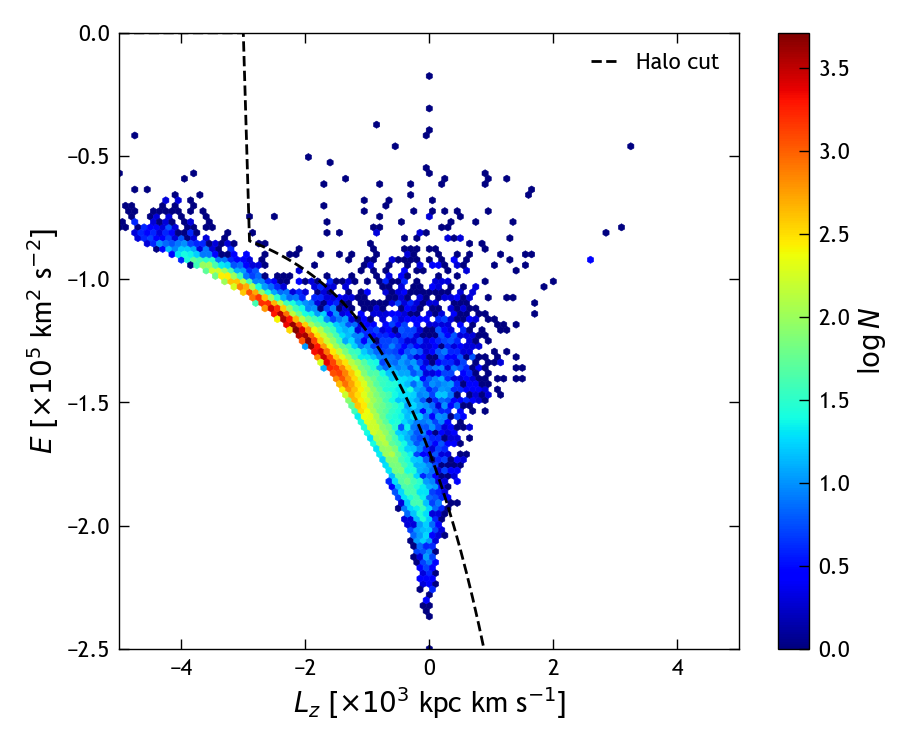

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))

logsum = lambda x: np.log10(np.sum(x))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-5, 5, -2.5, 0.])
pcm = ax.hexbin(
    mwm_rgb['Lz']/1e3, mwm_rgb['E']/1e5, 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

# Arbitrary cut - find a better one in the literature
def halo_ELz_cut(Lz):
    return np.where(Lz<-3, 0, -0.7 - np.exp(Lz / 1.5))

Lz_arr = np.arange(-5, 5.1, 0.1)
ax.plot(Lz_arr, halo_ELz_cut(Lz_arr), 'k--', label='Halo cut')

ax.set_xlabel(r'$L_z$ [$\times10^3$ kpc km s$^{-1}$]')
ax.set_ylabel(r'$E$ [$\times 10^5$ km$^2$ s$^{-2}$]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

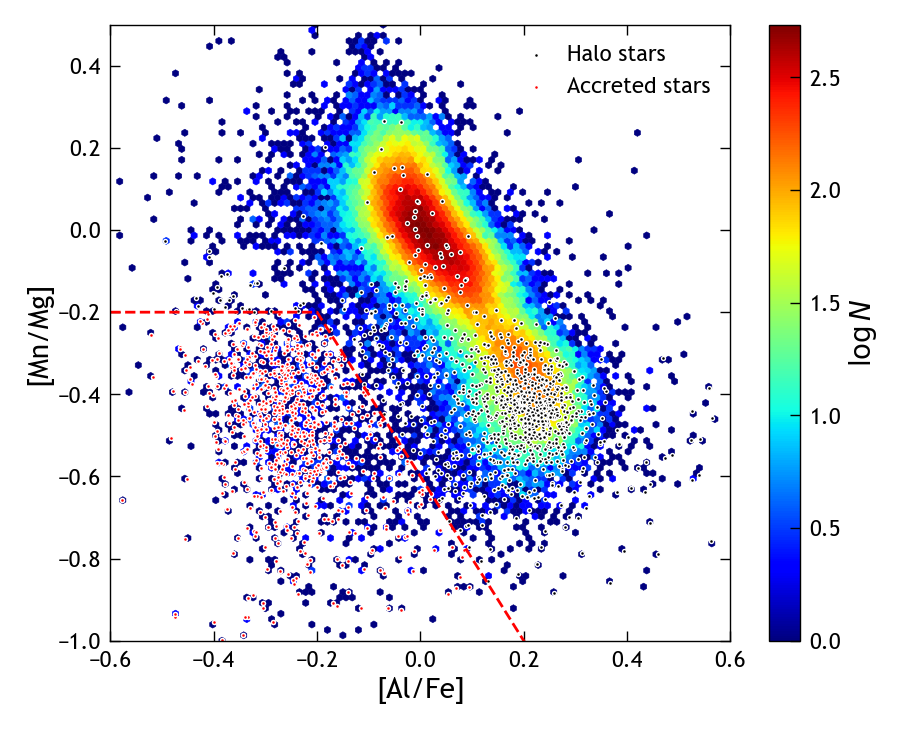

In [4]:
mwm_halo = mwm_rgb[mwm_rgb['E']/1e5 > halo_ELz_cut(mwm_rgb['Lz']/1e3)]
mwm_disk = mwm_rgb[mwm_rgb['E']/1e5 < halo_ELz_cut(mwm_rgb['Lz']/1e3)]

fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-0.6, 0.6, -1, 0.5])
pcm = ax.hexbin(
    mwm_rgb['al_fe'], mwm_rgb['mn_mg'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

ax.scatter(mwm_halo['al_fe'], mwm_halo['mn_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')

def accreted_boundary(alfe):
    return np.where(alfe > -0.2, -0.6-2*alfe, -0.2)

alfe_arr = np.arange(-0.6, 0.5, 0.1)
ax.plot(alfe_arr, accreted_boundary(alfe_arr), 'r--')

mwm_accreted = mwm_halo[mwm_halo['mn_mg'] < accreted_boundary(mwm_halo['al_fe'])]
mwm_halo_in_situ = mwm_halo[mwm_halo['mn_mg'] > accreted_boundary(mwm_halo['al_fe'])]
ax.scatter(mwm_accreted['al_fe'], mwm_accreted['mn_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='r', label='Accreted stars')

ax.set_xlabel('[Al/Fe]')
ax.set_ylabel('[Mn/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

In [13]:
ce_limits = mwm_rgb[mwm_rgb['']]

fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-2.5, 0.7, -1.5, 1.5])
pcm = ax.hexbin(
    mwm_rgb['mg_h'], mwm_rgb['ce_mg'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

# ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')
ax.scatter(ce_limits['mg_h'], ce_limits['ce_mg'], c='r', s=1, label='Upper limits')

# Indicate abundance upper limits
teff_arr = np.arange(3800, 5300, 100)
ax.plot(detection_limits(teff_arr, 100, mg_coeffs), detection_limits(teff_arr, 100, ce_coeffs))
print(detection_limits(teff_arr, 100, mg_coeffs))
print(detection_limits(teff_arr, 100, ce_coeffs))

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k--') # edge of stars flagged bad
ax.plot(mgh_arr, -1.6 - mgh_arr, 'r--') # indicates region of upper limits (manual)
ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k--') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

KeyError: ''

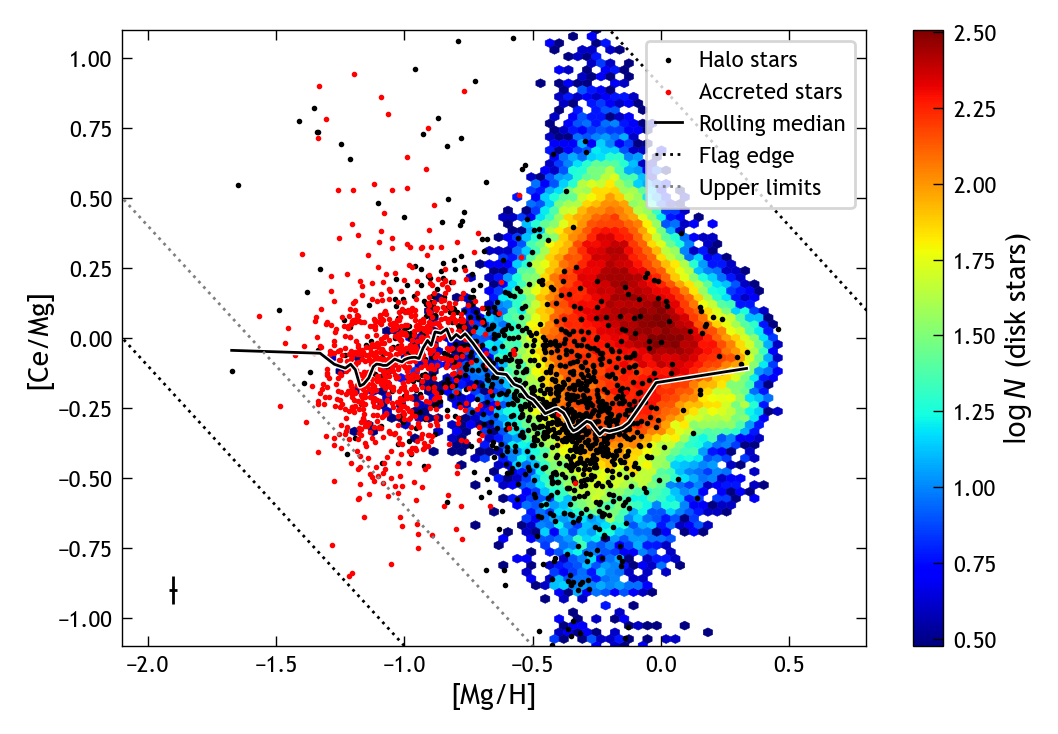

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

kwargs = dict(gridsize=80, cmap='jet', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
pcm = ax.hexbin(
    mwm_disk['mg_h'], mwm_disk['ce_mg'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(mwm_halo_in_situ['mg_h'], mwm_halo_in_situ['ce_mg'], rasterized=True, s=1, c='k', label='Halo stars')
ax.scatter(mwm_accreted['mg_h'], mwm_accreted['ce_mg'], rasterized=True, s=1, c='r', label='Accreted stars')

# Indicate median abundance error
ax.errorbar(
    -1.9, -0.9, 
    xerr=mwm_rgb['e_mg_h'].median(), 
    yerr=mwm_rgb['e_ce_mg'].median(),
    c='k', capsize=0
)

# Rolling median
sorted_data = mwm_halo.sort_values('mg_h')[['mg_h', 'ce_mg']]
rolling_medians = sorted_data.rolling(
    100, min_periods=30, step=30, on='mg_h', center=True
).median()
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'k-', label='Rolling median')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.6 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

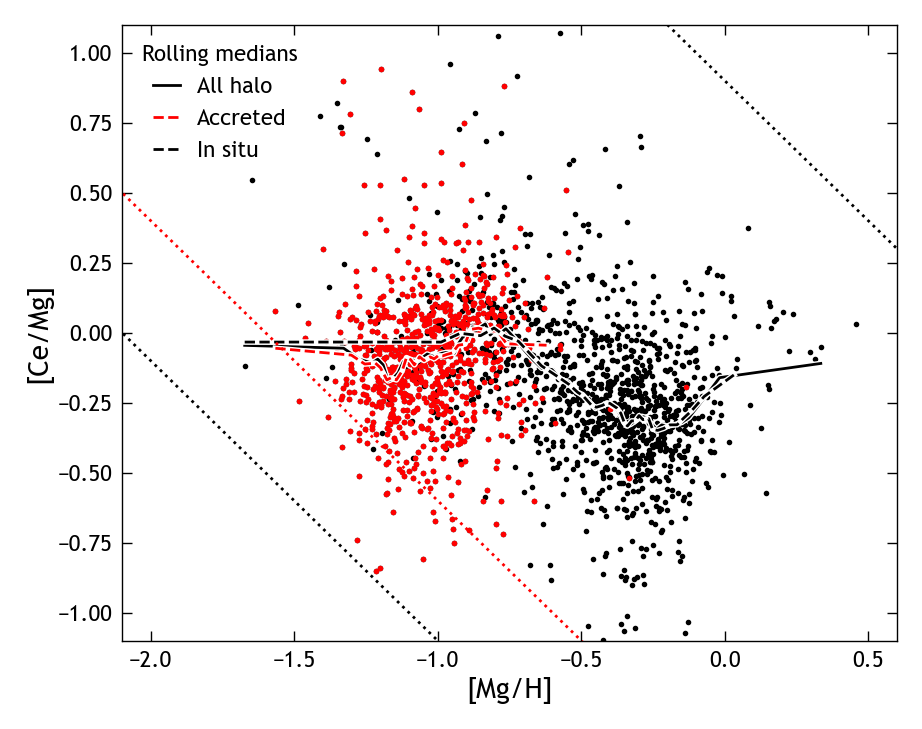

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, s=1, c='k')
ax.scatter(mwm_accreted['mg_h'], mwm_accreted['ce_mg'], rasterized=True, s=1, c='r')

# Rolling median
fmt = ['k-', 'r--', 'k--']
labels = ['All halo', 'Accreted', 'In situ']
for i, data in enumerate([mwm_halo, mwm_accreted, mwm_halo_in_situ]):
    sorted_data = data.sort_values('mg_h')[['mg_h', 'ce_mg']]
    rolling_medians = sorted_data.rolling(
        100, min_periods=30, step=30, on='mg_h', center=True
    ).median()
    ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
    ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], fmt[i], label=labels[i])

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:') # edge of stars flagged bad
ax.plot(mgh_arr, -1.6 - mgh_arr, 'r:') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-2.1, 0.6))
ax.set_ylim((-1.1, 1.1))
ax.legend(title='Rolling medians')

plt.show()

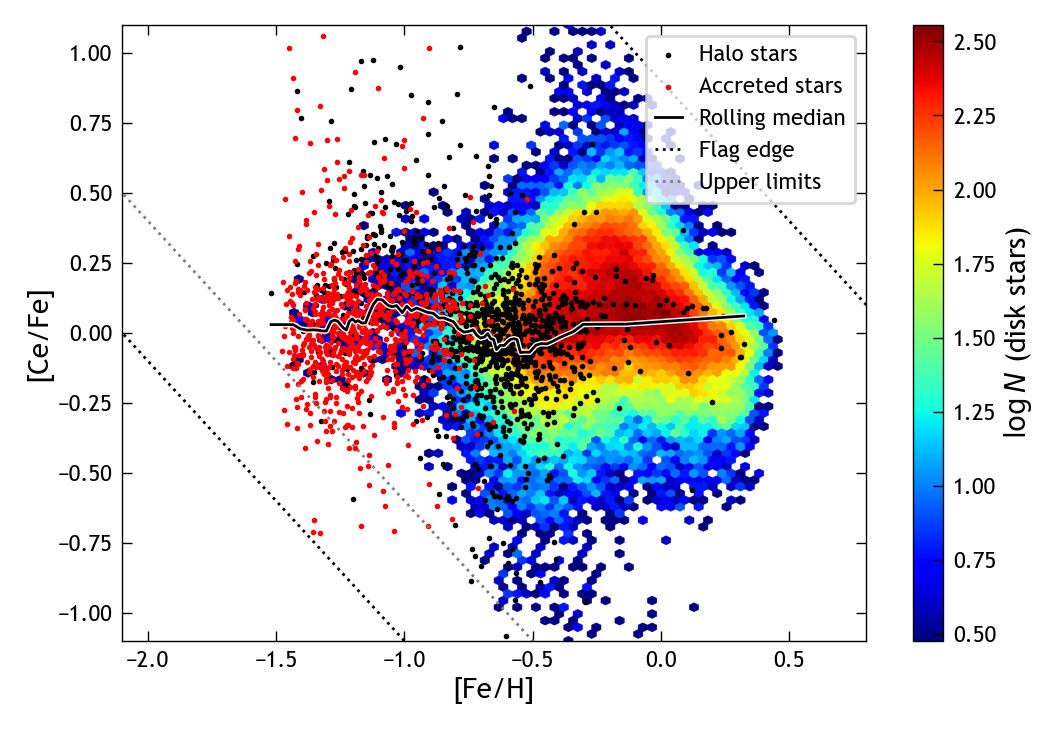

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

kwargs = dict(gridsize=80, cmap='jet', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
pcm = ax.hexbin(
    mwm_disk['fe_h'], mwm_disk['ce_fe'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(mwm_halo_in_situ['fe_h'], mwm_halo_in_situ['ce_fe'], rasterized=True, s=1, c='k', label='Halo stars')
ax.scatter(mwm_accreted['fe_h'], mwm_accreted['ce_fe'], rasterized=True, s=1, c='r', label='Accreted stars')

# Rolling median
sorted_data = mwm_halo.sort_values('fe_h')[['fe_h', 'ce_fe']]
rolling_medians = sorted_data.rolling(
    100, min_periods=30, step=30, on='fe_h', center=True
).median()
ax.plot(rolling_medians['fe_h'], rolling_medians['ce_fe'], 'w-', linewidth=2)
ax.plot(rolling_medians['fe_h'], rolling_medians['ce_fe'], 'k-', label='Rolling median')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.6 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

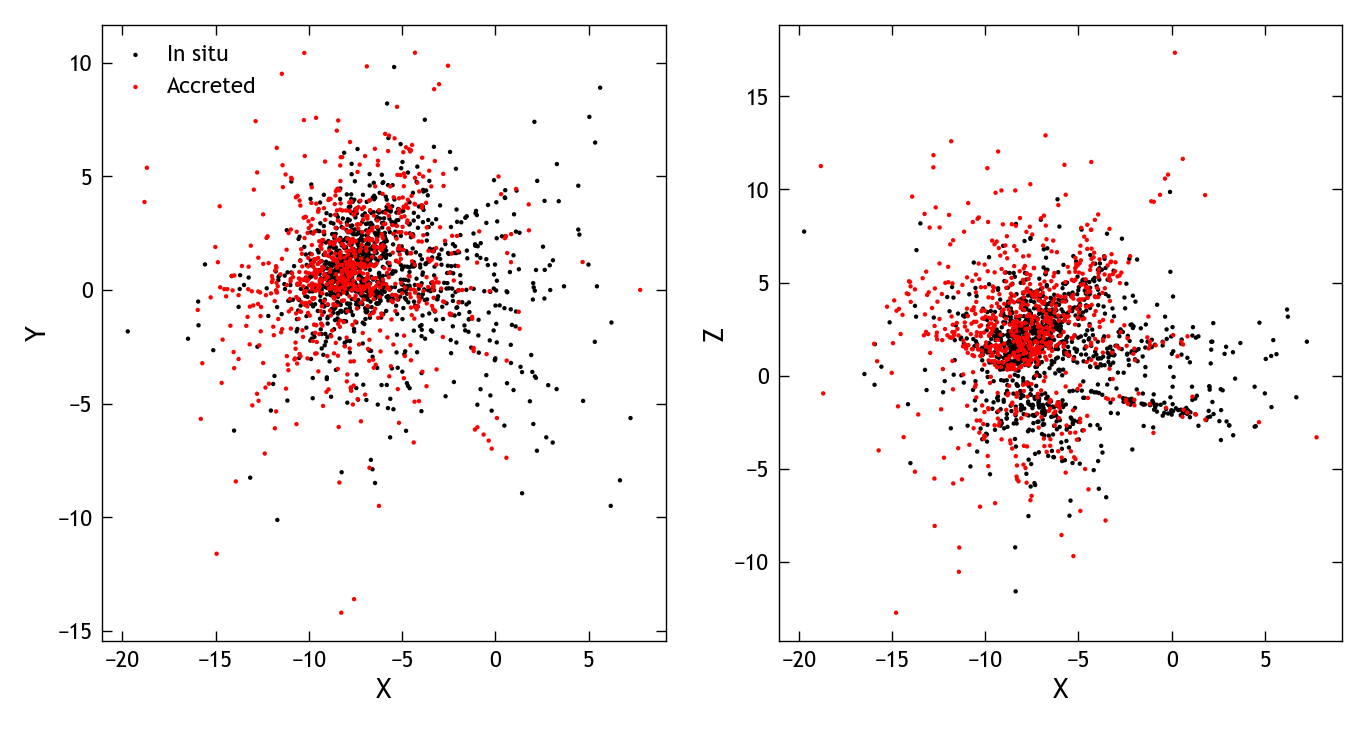

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
scatter_kwargs = dict(s=10, marker='.', edgecolors='none')
axs[0].scatter(mwm_halo_in_situ['galx'], mwm_halo_in_situ['galy'], c='k', label='In situ', **scatter_kwargs)
axs[0].scatter(mwm_accreted['galx'], mwm_accreted['galy'], c='r', label='Accreted', **scatter_kwargs)
axs[1].scatter(mwm_halo_in_situ['galx'], mwm_halo_in_situ['galz'], c='k', **scatter_kwargs)
axs[1].scatter(mwm_accreted['galx'], mwm_accreted['galz'], c='r',  **scatter_kwargs)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Z')
axs[0].legend()
plt.show()

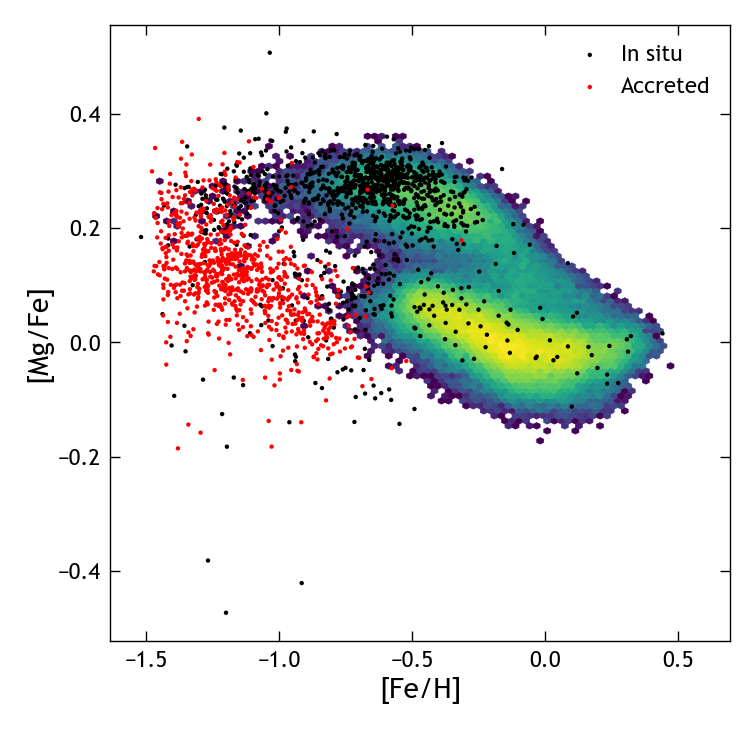

In [9]:
fig, ax = plt.subplots()
kwargs = dict(gridsize=80, cmap='viridis', linewidths=0.2, mincnt=3)
pcm = ax.hexbin(
    mwm_disk['fe_h'], mwm_disk['mg_fe'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
ax.scatter(mwm_halo_in_situ['fe_h'], mwm_halo_in_situ['mg_fe'], c='k', label='In situ', **scatter_kwargs)
ax.scatter(mwm_accreted['fe_h'], mwm_accreted['mg_fe'], c='r', label='Accreted', **scatter_kwargs)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
ax.legend()
plt.show()

In [10]:
mwm_rgb['vy'].median()

np.float64(215.2118202631817)

          sdss_id     sdss4_apogee_id   gaia_dr2_source_id  \
5400     55134242                 NaN   498409449802310912   
6344     55314204                 NaN   514379512607147904   
9522     55777478                 NaN   579140163356890240   
9922     55817175  2M09240139+0506566   585503312024810496   
9937     55818064  2M09240780+0549203   585682562484368896   
...           ...                 ...                  ...   
119640  117042003  2M00403256+3319432   361876528269437568   
119682  117081399  2M00392278+3915218   368620034945552768   
119776  117246717  2M00375433+4936028   391444629326689536   
120260  117524821  2M00013487+5556502   420902366906422656   
120693  129056837  2M17352406-4010270  5960855367752157440   

         gaia_dr3_source_id   tic_v8_id  healpix             lead  version_id  \
5400     498409449802310912   138023107     4559           tic_v8          25   
6344     514379512607147904   458883578     9968           tic_v8          25   
9522     579

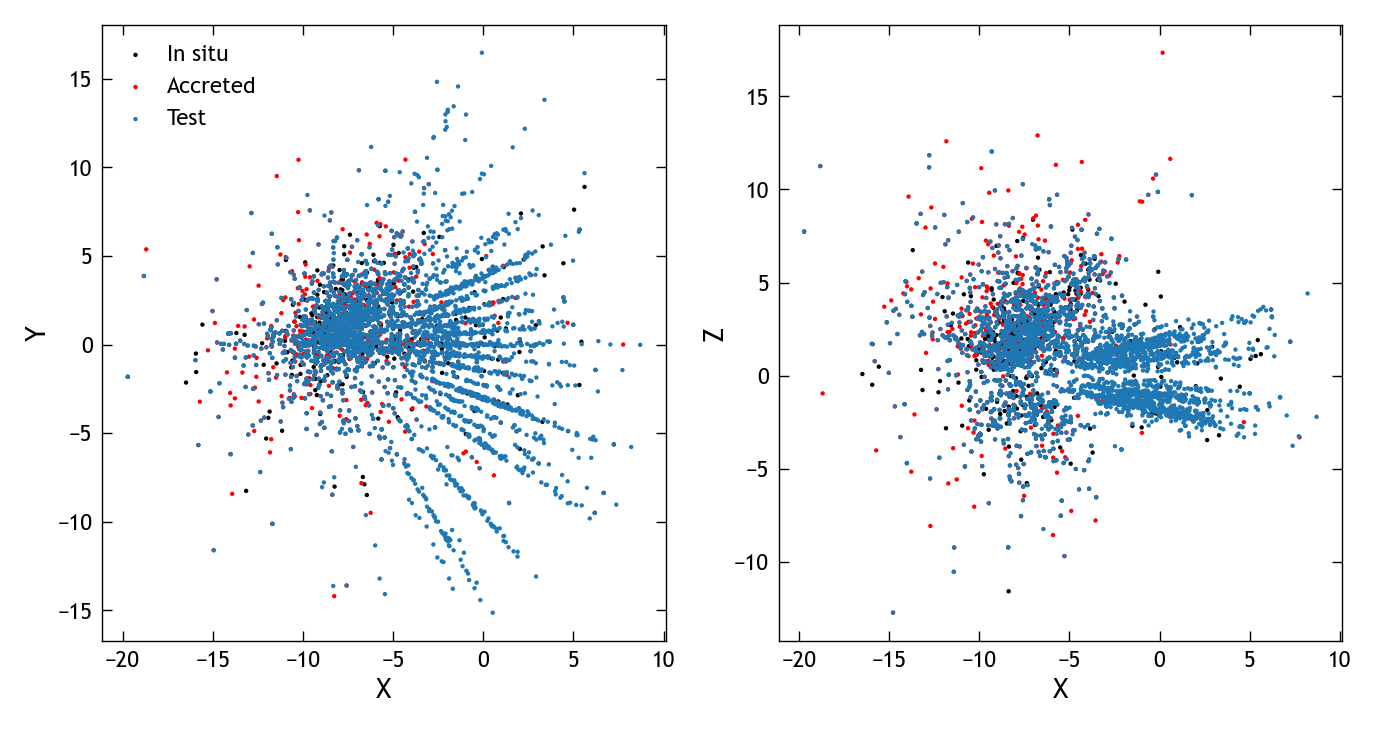

In [11]:
# Test velocity-based halo separation
mwm_halo_vel = mwm_rgb[np.abs(mwm_rgb['vy'] - 251.8) > 210]
print(mwm_halo_vel)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(mwm_halo_in_situ['galx'], mwm_halo_in_situ['galy'], c='k', label='In situ', **scatter_kwargs)
axs[0].scatter(mwm_accreted['galx'], mwm_accreted['galy'], c='r', label='Accreted', **scatter_kwargs)
axs[0].scatter(mwm_halo_vel['galx'], mwm_halo_vel['galy'], label='Test', **scatter_kwargs)
axs[1].scatter(mwm_halo_in_situ['galx'], mwm_halo_in_situ['galz'], c='k', **scatter_kwargs)
axs[1].scatter(mwm_accreted['galx'], mwm_accreted['galz'], c='r',  **scatter_kwargs)
axs[1].scatter(mwm_halo_vel['galx'], mwm_halo_vel['galz'], label='Test', **scatter_kwargs)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Z')
axs[0].legend()
plt.show()

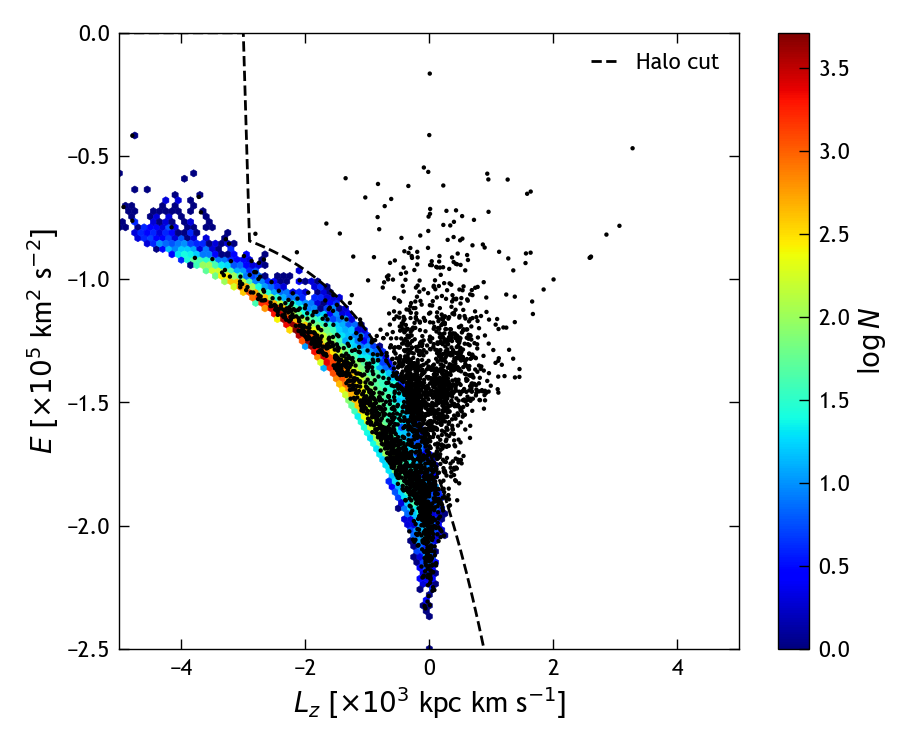

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))

logsum = lambda x: np.log10(np.sum(x))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-5, 5, -2.5, 0.])
pcm = ax.hexbin(
    mwm_disk['Lz']/1e3, mwm_disk['E']/1e5, 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

# Arbitrary cut - find a better one in the literature
def halo_ELz_cut(Lz):
    return np.where(Lz<-3, 0, -0.7 - np.exp(Lz / 1.5))

Lz_arr = np.arange(-5, 5.1, 0.1)
ax.plot(Lz_arr, halo_ELz_cut(Lz_arr), 'k--', label='Halo cut')

ax.scatter(mwm_halo_vel['Lz']/1e3, mwm_halo_vel['E']/1e5, c='k', **scatter_kwargs)

ax.set_xlabel(r'$L_z$ [$\times10^3$ kpc km s$^{-1}$]')
ax.set_ylabel(r'$E$ [$\times 10^5$ km$^2$ s$^{-2}$]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_77906/1748696668.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


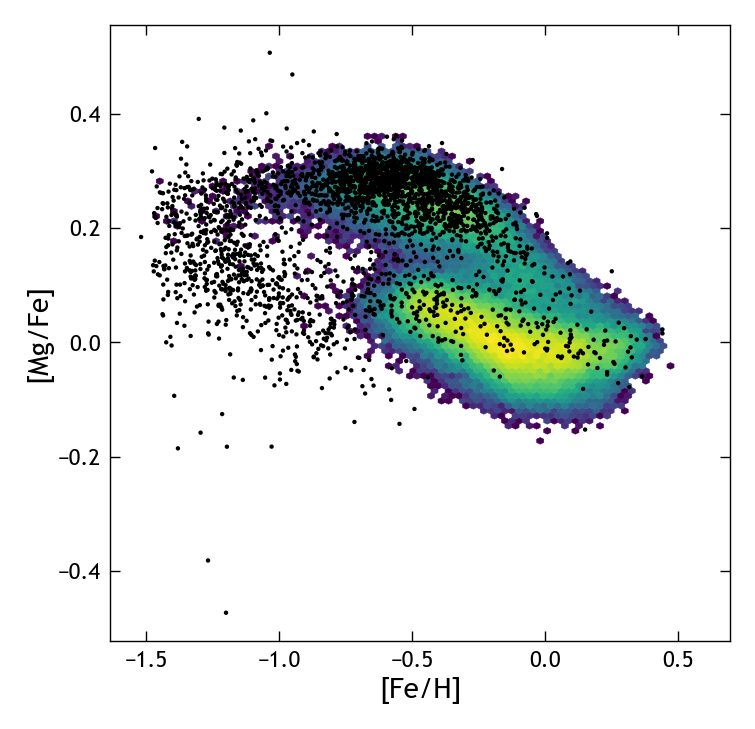

In [13]:
fig, ax = plt.subplots()
kwargs = dict(gridsize=80, cmap='viridis', linewidths=0.2, mincnt=3)
pcm = ax.hexbin(
    mwm_disk['fe_h'], mwm_disk['mg_fe'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
ax.scatter(mwm_halo_vel['fe_h'], mwm_halo_vel['mg_fe'], c='k', **scatter_kwargs)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
ax.legend()
plt.show()

In [14]:
mwm_accreted['ce_mg'].median()

np.float64(-0.082677424)

In [15]:
mwm_accreted['ce_mg'].mean()

np.float64(-0.08548281967433455)

In [16]:
median_standard_error(mwm_accreted['ce_mg'])

np.float64(0.008616514947817018)

In [17]:
mwm_halo_in_situ['ce_mg'].median()

np.float64(-0.22137737)

In [18]:
mwm_halo_in_situ['ce_mg'].mean()

np.float64(-0.20292801463729038)

In [19]:
median_standard_error(mwm_halo_in_situ['ce_mg'])

np.float64(0.009276069085028196)

In [20]:
mwm_disk[mwm_disk['low_alpha']]['ce_mg'].mean()

np.float64(0.0847824575142017)

In [21]:
logg_arr = np.arange(1, 4, 0.5)
logg_groups = mwm_halo.groupby(pd.cut(mwm_halo['logg'], logg_arr), observed=False)
logg_groups.count()

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
logg,,,,,,,,,,,,,,,,,,,,,
"(1.0, 1.5]",570,388,570,570,570,570,570,570,570,570,...,570,570,570,570,570,570,570,570,570,570
"(1.5, 2.0]",567,415,567,567,567,567,567,567,567,567,...,567,567,567,567,567,567,567,567,567,567
"(2.0, 2.5]",570,431,570,570,570,570,570,570,570,570,...,570,570,570,570,570,570,570,570,570,570
"(2.5, 3.0]",191,135,191,191,191,191,191,191,191,191,...,191,191,191,191,191,191,191,191,191,191
"(3.0, 3.5]",54,41,54,54,54,54,54,54,54,54,...,54,54,54,54,54,54,54,54,54,54


In [22]:
(54+191)/(570+567+570+191+54)

0.1255122950819672